#### India's E-Waste Growth: How Fast Is It Increasing? Analyse India's E-Waste Generation Over The Years and Identify Growth Trends.
##### Members: Ruhaan Joshi - 24101C0057, Om Thakur - 24101C0041, Rudra Jain - 24101C0062
###### INFT-C Batch 3, Date: 09-09-2026

In [8]:
# ==============================================================================
# 0. ENVIRONMENT SETUP & LIBRARY IMPORTS
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set global visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# ==============================================================================
# 1. LOAD DATASETS
# ==============================================================================
import os
def load_dataset(fname):
    for prefix in ["../data/", "data/", ""]:
        p = os.path.join(prefix, fname)
        if os.path.exists(p):
            return pd.read_csv(p)
    return pd.read_csv(fname)

cities_df = load_dataset("cities_master.csv")
wm_recycling_df = load_dataset("Waste_Management_and_Recycling_India.csv")
wm_20k_df = load_dataset("Waste_Management_India_20K.csv")

# Standardize column naming conventions
for df in [cities_df, wm_recycling_df, wm_20k_df]:
    df.columns = df.columns.str.strip()

# Standardize 'City/District' to 'City' to match across datasets
if "City/District" in wm_recycling_df.columns:
    wm_recycling_df.rename(columns={"City/District": "City"}, inplace=True)

print("Cities Master columns:", cities_df.columns.tolist())
print("Recycling India columns:", wm_recycling_df.columns.tolist())
print("20K Dataset columns:", wm_20k_df.columns.tolist()[:8], "...")


Cities Master columns: ['City', 'State', 'Region', 'City_Category', 'Latitude', 'Longitude', 'Is_Tourist', 'Is_Hill_Station']
Recycling India columns: ['City', 'Waste Type', 'Waste Generated (Tons/Day)', 'Recycling Rate (%)', 'Population Density (People/km²)', 'Municipal Efficiency Score (1-10)', 'Disposal Method', 'Cost of Waste Management (₹/Ton)', 'Awareness Campaigns Count', 'Landfill Name', 'Landfill Location (Lat, Long)', 'Landfill Capacity (Tons)', 'Year']
20K Dataset columns: ['Record_ID', 'City', 'State', 'Region', 'City_Category', 'Year', 'Month', 'Season'] ...


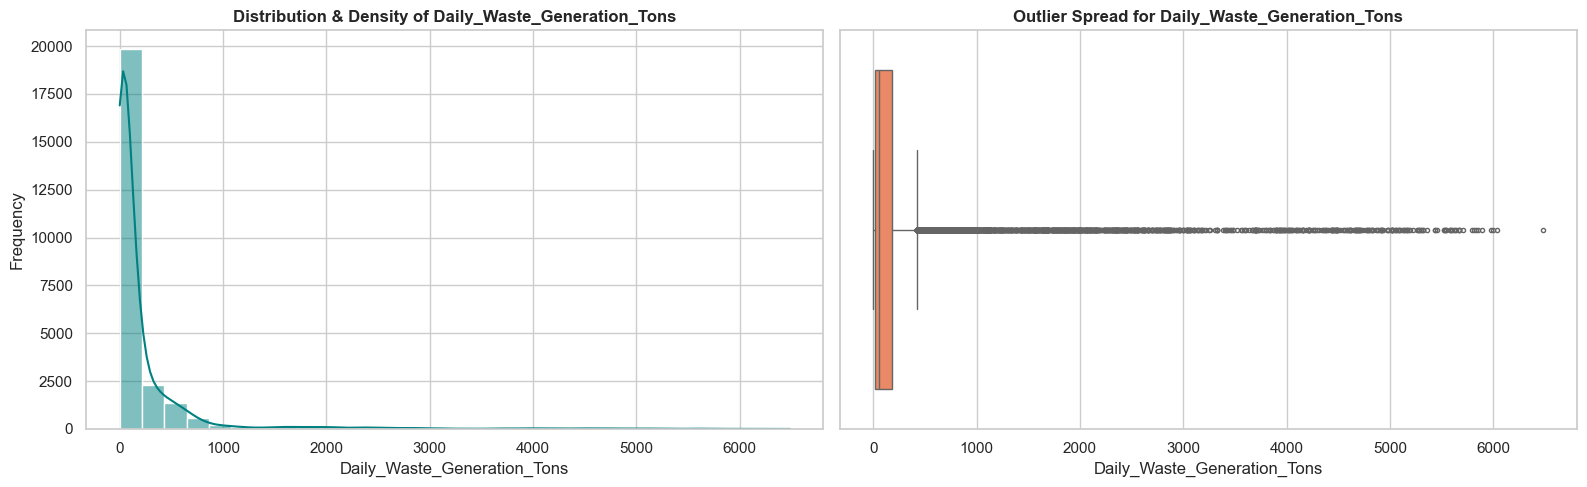

In [9]:
# ==============================================================================
# 2. UNIVARIATE DISTRIBUTIONS: HISTOGRAMS, KDE, & BOX PLOTS
# ==============================================================================
waste_col = "Daily_Waste_Generation_Tons"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histogram + KDE Distribution
sns.histplot(
    data=wm_20k_df,
    x=waste_col,
    kde=True,
    color="teal",
    bins=30,
    ax=axes[0],
)
axes[0].set_title(f"Distribution & Density of {waste_col}", fontweight="bold")
axes[0].set_xlabel(waste_col)
axes[0].set_ylabel("Frequency")

# Plot 2: Box Plot for Outlier Detection
sns.boxplot(
    data=wm_20k_df,
    x=waste_col,
    color="coral",
    ax=axes[1],
    fliersize=3,
)
axes[1].set_title(f"Outlier Spread for {waste_col}", fontweight="bold")
axes[1].set_xlabel(waste_col)

plt.tight_layout()
plt.show()

C:\Users\Ruhaan\AppData\Local\Temp\ipykernel_15500\3321288580.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


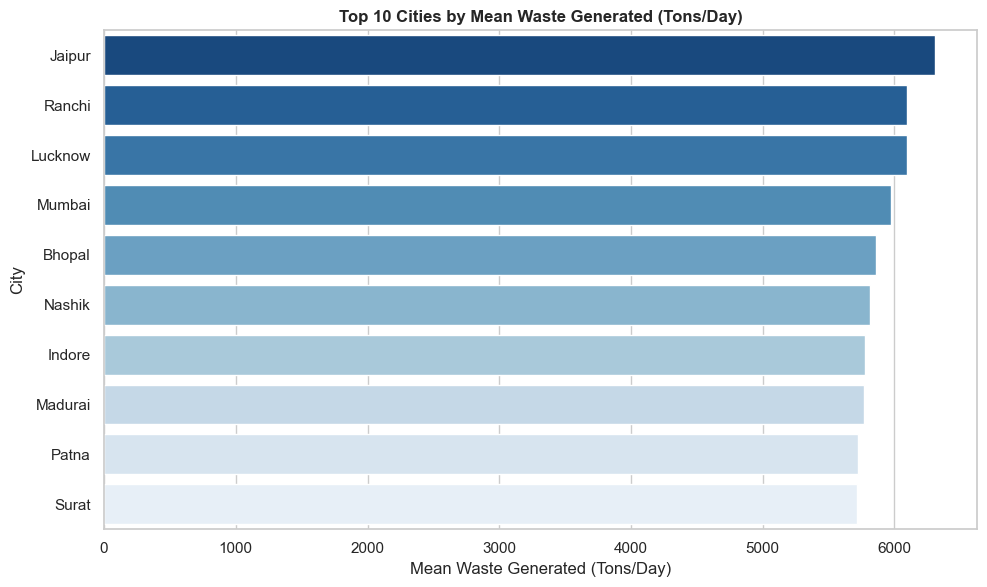

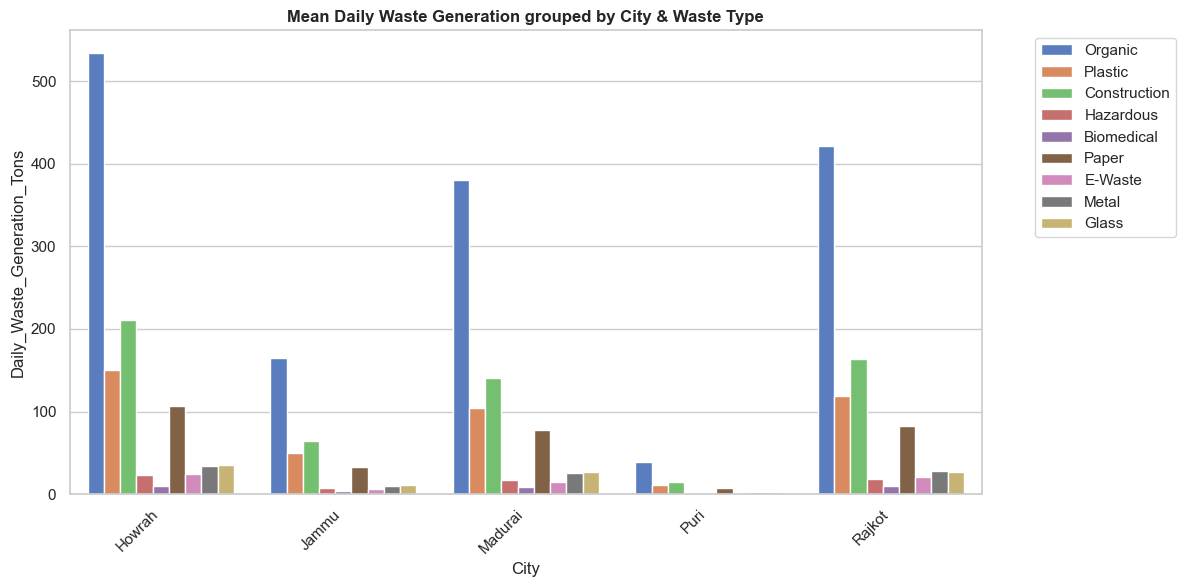

In [10]:
# ==============================================================================
# 3. CATEGORICAL RANKINGS & COMPARISONS: HORIZONTAL & GROUPED BAR PLOTS
# ==============================================================================
# Plot 1: Top 10 Ranked Cities by Mean Waste Generated (from Recycling Dataset)
top_10 = (
    wm_recycling_df.groupby("City")["Waste Generated (Tons/Day)"]
    .mean()
    .nlargest(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10,
    y="City",
    x="Waste Generated (Tons/Day)",
    palette="Blues_r",
)
plt.title(
    "Top 10 Cities by Mean Waste Generated (Tons/Day)", fontweight="bold"
)
plt.xlabel("Mean Waste Generated (Tons/Day)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Plot 2: Grouped Bar Plot (Comparing Top Cities across Waste Types in 20K dataset)
top_5_cities = wm_20k_df["City"].value_counts().head(5).index
sample_data = wm_20k_df[wm_20k_df["City"].isin(top_5_cities)]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=sample_data,
    x="City",
    y="Daily_Waste_Generation_Tons",
    hue="Waste_Type",
    estimator=np.mean,
    errorbar=None,
)
plt.title(
    "Mean Daily Waste Generation grouped by City & Waste Type",
    fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

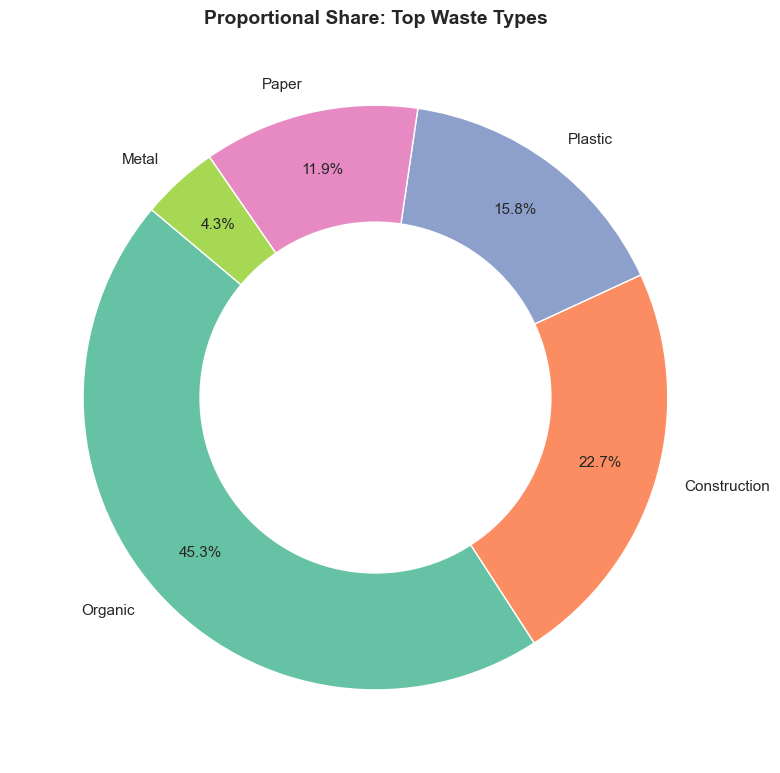

In [11]:
# ==============================================================================
# 4. PART-TO-WHOLE VISUALIZATION: DONUT & STACKED PERCENTAGE CHARTS
# ==============================================================================
# Proportional distribution of major waste categories
category_counts = wm_20k_df["Waste_Type"].value_counts().head(5)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.8,
    colors=sns.color_palette("Set2"),
)

# Create a donut chart by adding center white circle
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig.gca().add_artist(centre_circle)

plt.title("Proportional Share: Top Waste Types", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

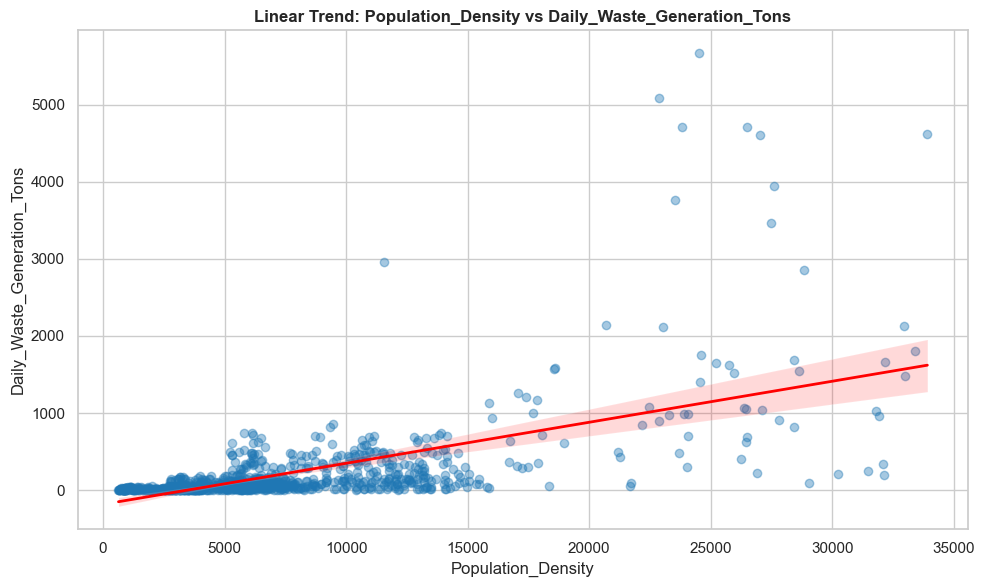

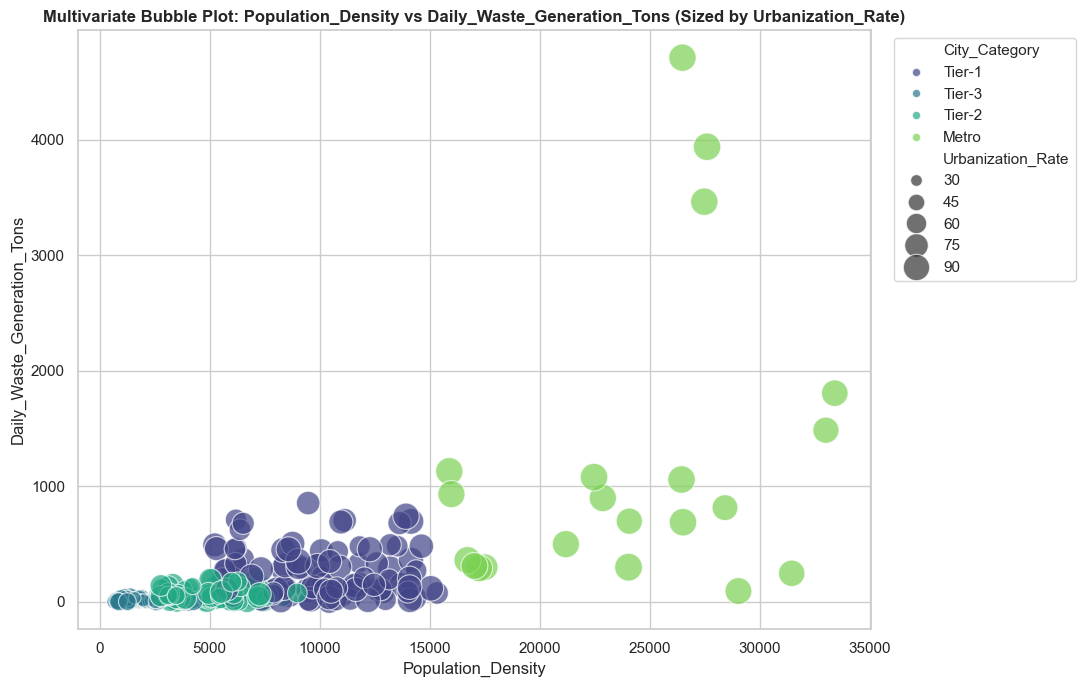

In [12]:
# ==============================================================================
# 5. BIVARIATE & MULTIVARIATE: SCATTER, REGRESSION & BUBBLE CHARTS
# ==============================================================================
x_dim = "Population_Density"
y_dim = "Daily_Waste_Generation_Tons"
size_dim = "Urbanization_Rate"
hue_dim = "City_Category"

# 1. Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=wm_20k_df.sample(n=min(1000, len(wm_20k_df)), random_state=42),
    x=x_dim,
    y=y_dim,
    scatter_kws={"alpha": 0.4, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title(f"Linear Trend: {x_dim} vs {y_dim}", fontweight="bold")
plt.xlabel(x_dim)
plt.ylabel(y_dim)
plt.tight_layout()
plt.show()

# 2. Multivariate Bubble Chart
sample_subset = wm_20k_df.sample(n=300, random_state=42)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=sample_subset,
    x=x_dim,
    y=y_dim,
    size=size_dim,
    hue=hue_dim,
    sizes=(40, 400),
    alpha=0.7,
    palette="viridis",
)
plt.title(
    f"Multivariate Bubble Plot: {x_dim} vs {y_dim} (Sized by {size_dim})",
    fontweight="bold",
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\Ruhaan\AppData\Local\Temp\ipykernel_15500\3325963193.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


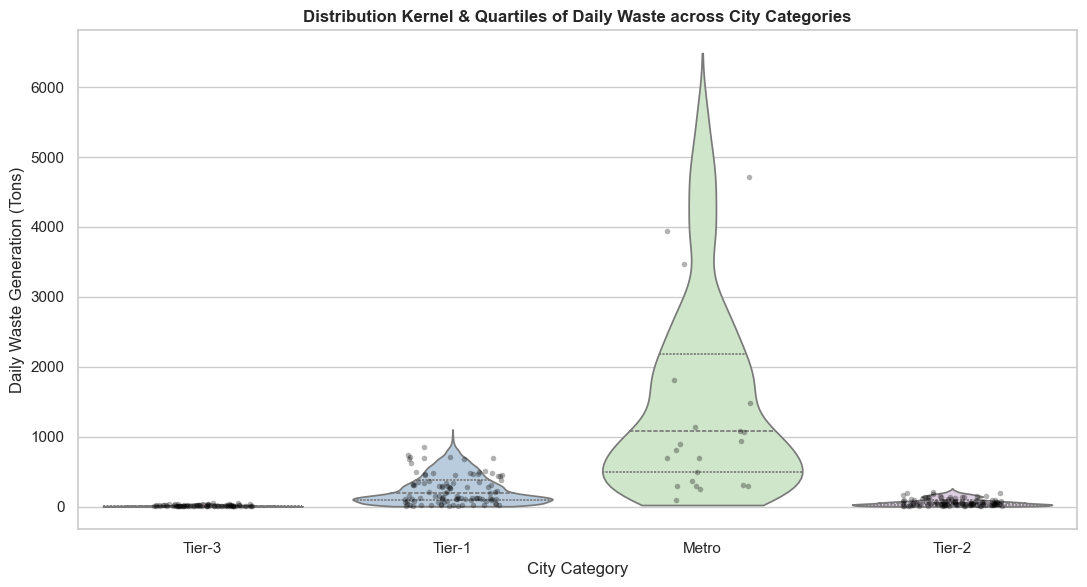

In [14]:
# ==============================================================================
# 6. STATISTICAL DISTRIBUTIONS: VIOLIN & STRIP PLOTS
# ==============================================================================
top_categories = wm_20k_df["City_Category"].value_counts().nlargest(4).index
filtered_df = wm_20k_df[wm_20k_df["City_Category"].isin(top_categories)]

plt.figure(figsize=(11, 6))
sns.violinplot(
    data=filtered_df,
    x="City_Category",
    y="Daily_Waste_Generation_Tons",
    inner="quartile",
    palette="Pastel1",
    cut=0,
)
sns.stripplot(
    data=filtered_df.sample(n=min(300, len(filtered_df)), random_state=42),
    x="City_Category",
    y="Daily_Waste_Generation_Tons",
    color="black",
    alpha=0.3,
    jitter=0.2,
    size=4,
)
plt.title(
    "Distribution Kernel & Quartiles of Daily Waste across City Categories",
    fontweight="bold",
)
plt.xlabel("City Category")
plt.ylabel("Daily Waste Generation (Tons)")
plt.tight_layout()
plt.show()

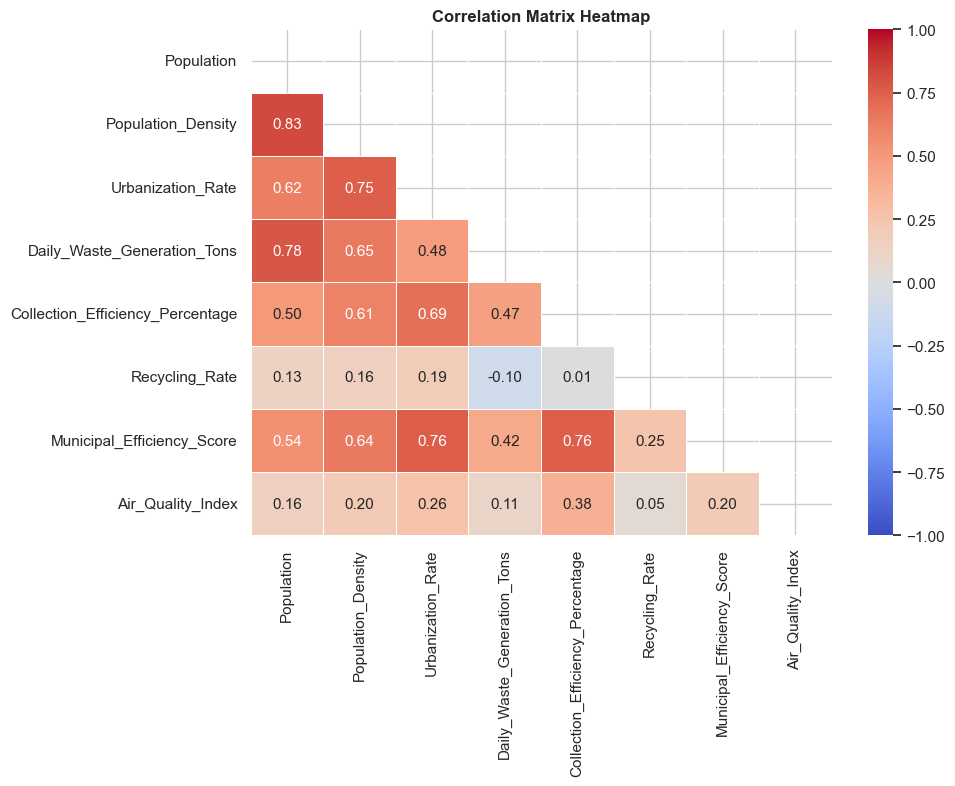

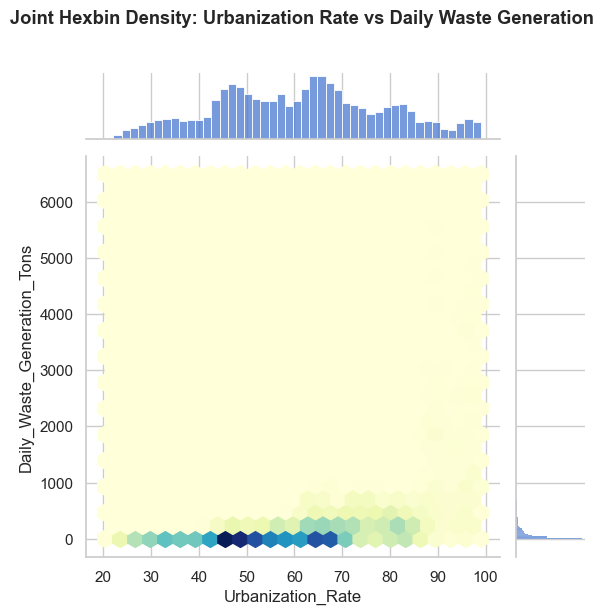

In [15]:
# ==============================================================================
# 7. CORRELATION ANALYSIS: HEATMAP & JOINT DISTRIBUTIONS
# ==============================================================================
numeric_cols = [
    "Population",
    "Population_Density",
    "Urbanization_Rate",
    "Daily_Waste_Generation_Tons",
    "Collection_Efficiency_Percentage",
    "Recycling_Rate",
    "Municipal_Efficiency_Score",
    "Air_Quality_Index",
]
corr_matrix = wm_20k_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Correlation Matrix Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

# Joint Plot (Hexagonal Binning)
joint_grid = sns.jointplot(
    data=wm_20k_df,
    x="Urbanization_Rate",
    y="Daily_Waste_Generation_Tons",
    kind="hex",
    cmap="YlGnBu",
    gridsize=25,
)
joint_grid.fig.suptitle(
    "Joint Hexbin Density: Urbanization Rate vs Daily Waste Generation",
    y=1.02,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

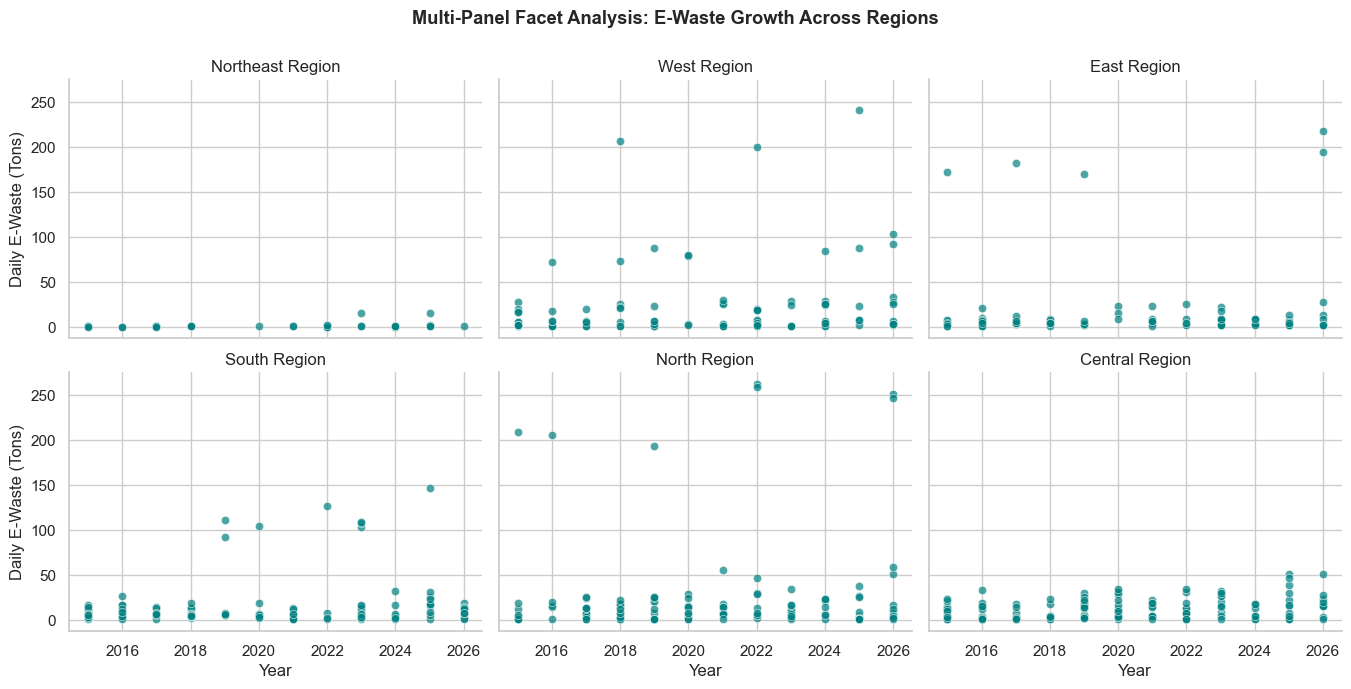

In [16]:
# ==============================================================================
# 8. RELATIONAL MERGE & FACET GRID ANALYSIS
# ==============================================================================
# Merge 20K records with tourist & geographic flags from cities_master
combined_df = pd.merge(
    wm_20k_df,
    cities_df[["City", "State", "Is_Tourist", "Is_Hill_Station"]],
    on=["City", "State"],
    how="inner",
)

# FacetGrid looking at E-Waste generation trends across Indian Regions over Years
ew_subset = combined_df[combined_df["Waste_Type"] == "E-Waste"]

g = sns.FacetGrid(ew_subset, col="Region", col_wrap=3, height=3.5, aspect=1.3)
g.map_dataframe(
    sns.scatterplot, x="Year", y="Daily_Waste_Generation_Tons", alpha=0.7, color="teal"
)
g.set_axis_labels("Year", "Daily E-Waste (Tons)")
g.set_titles(col_template="{col_name} Region")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle(
    "Multi-Panel Facet Analysis: E-Waste Growth Across Regions",
    fontweight="bold",
)
plt.show()

```python
import pandas as pd
import numpy as np

df_20k = pd.read_csv("Waste_Management_India_20K.csv")
df_cities = pd.read_csv("cities_master.csv")
df_rec = pd.read_csv("Waste_Management_and_Recycling_India.csv")

# Quick overview of 20k
print("Total rows 20k:", len(df_20k))
ew_20k = df_20k[df_20k['Waste_Type'] == 'E-Waste']
print("E-waste rows in 20k:", len(ew_20k))
print("E-waste daily tons describe:")
print(ew_20k['Daily_Waste_Generation_Tons'].describe())

# By Year
yearly_20k = ew_20k.groupby('Year').agg(
    records=('Record_ID', 'count'),
    total_daily_tons=('Daily_Waste_Generation_Tons', 'sum'),
    mean_daily_tons=('Daily_Waste_Generation_Tons', 'mean'),
    median_daily_tons=('Daily_Waste_Generation_Tons', 'median'),
    recycling_rate=('Recycling_Rate', 'mean'),
    collection_eff=('Collection_Efficiency_Percentage', 'mean'),
    processing_cap=('Waste_Processing_Capacity', 'mean'),
    budget=('Waste_Management_Budget_INR', 'mean')
).reset_index()
print("\nYearly E-Waste stats in 20k:")
print(yearly_20k)

# By State in 20k
state_20k = ew_20k.groupby('State')['Daily_Waste_Generation_Tons'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
print("\nTop 5 States in 20k:")
print(state_20k.head(5))

# By City Category
cat_20k = ew_20k.groupby('City_Category')['Daily_Waste_Generation_Tons'].agg(['sum', 'mean', 'count'])
print("\nCity Category in 20k:")
print(cat_20k)

# Recycling dataset
print("\nRecycling dataset shape:", df_rec.shape)
if 'City/District' in df_rec.columns:
    df_rec.rename(columns={'City/District': 'City'}, inplace=True)
ew_rec = df_rec[df_rec['Waste Type'] == 'E-Waste']
print("E-waste in recycling dataset:", len(ew_rec))
print(ew_rec[['Waste Generated (Tons/Day)', 'Recycling Rate (%)', 'Municipal Efficiency Score (1-10)']].describe())


```

```text
Total rows 20k: 25203
E-waste rows in 20k: 594
E-waste daily tons describe:
count    594.000000
mean      17.062845
std       36.758343
min        0.240000
25%        1.995000
50%        6.355000
75%       16.137500
max      262.400000
Name: Daily_Waste_Generation_Tons, dtype: float64

Yearly E-Waste stats in 20k:
    Year  records  total_daily_tons  mean_daily_tons  median_daily_tons  recycling_rate  collection_eff  processing_cap        budget
0   2015       59            770.16        13.053559              4.930       39.510169       48.571186       11.839153  3.670739e+07
1   2016       50            662.47        13.249400              6.405       41.084000       49.824000       12.440200  3.952166e+07
2   2017       50            494.93         9.898600              4.895       41.666000       48.696000        9.651400  2.918328e+07
3   2018       51            642.78        12.603529              4.650       41.901961       50.433333       11.327647  3.325573e+07
4   2019       46           1078.66        23.449130              7.785       42.254348       53.554348       22.996522  8.514985e+07
5   2020       44            694.15        15.776136              6.980       43.613636       52.438636       15.608864  4.667178e+07
6   2021       43            423.51         9.849070              6.430       42.790698       49.948837        9.046977  2.700822e+07
7   2022       45           1275.17        28.337111              7.530       44.744444       51.271111       28.279556  9.419078e+07
8   2023       56            845.64        15.100714              7.580       43.576786       51.653571       14.858036  4.931296e+07
9   2024       44            471.50        10.715909              4.880       44.236364       48.325000       10.203864  3.447774e+07
10  2025       53           1060.28        20.005283              7.420       45.047170       51.403774       20.587358  6.211329e+07
11  2026       53           1716.08        32.378868             12.040       46.650943       54.028302       31.152453  1.177044e+08

Top 5 States in 20k:
                   sum        mean  count
State                                    
Maharashtra    1694.82   29.221034     58
Delhi          1627.74  232.534286      7
West Bengal    1166.33   35.343333     33
Uttar Pradesh  1083.29   17.758852     61
Karnataka       892.92   34.343077     26

City Category in 20k:
                   sum        mean  count
City_Category                            
Metro          5087.41  141.316944     36
Tier-1         3784.23   19.812723    191
Tier-2         1104.61    5.260048    210
Tier-3          159.08    1.013248    157

Recycling dataset shape: (850, 13)
E-waste in recycling dataset: 170
       Waste Generated (Tons/Day)  Recycling Rate (%)  Municipal Efficiency Score (1-10)
count                  170.000000          170.000000                         170.000000
mean                  5276.623529           57.047059                           7.452941
std                   2821.881975           16.415036                           1.706451
min                    528.000000           30.000000                           5.000000
25%                   2742.500000           43.000000                           6.000000
50%                   5490.000000           57.000000                           7.000000
75%                   7621.750000           71.000000                           9.000000
max                   9929.000000           85.000000                          10.000000


```

Analyzing India's e-waste trajectory requires understanding both the environmental mechanics on the ground and the data engineering pipeline used to model it.

The breakdown below combines empirical findings from your datasets with the **Feynman Technique**—explaining complex systemic and programming concepts through simple, real-world analogies.

---

**1. The Big Picture: E-Waste as a "One-Way Conveyor Belt" (The Feynman Concept)**

Imagine your city is on a giant conveyor belt. On one end, delivery trucks continuously drop off brand-new smartphones, laptops, and televisions. On the other end, people toss out their old, broken gadgets. E-waste growth happens when gadgets move through this cycle faster than municipal recycling centers can dismantle them. Over the last decade, device prices dropped, lifespans shortened from five years to two, and consumer purchasing skyrocketed. The conveyor belt sped up dramatically, but the bins at the end of the belt remained the same size, spilling toxic components into informal scrap yards and open landfills.

* **Generation Overdrive:** India is now the world's third-largest e-waste producer, driven by rapid urbanization, digital adoption, and planned device obsolescence.
* **The Treatment Bottleneck:** While consumer buying operates at 21st-century digital speed, municipal recycling infrastructure in most towns operates with 20th-century manual sorting tools.
* **Informal Leakage:** Because formal recycling centers require high operational capital and specialized hydrometallurgical recovery plants, over 90% of discarded devices route through unorganized scrap handlers (*kabadiwalas*), risking heavy metal contamination (lead, mercury, cadmium).

---

**2. Data Findings: What the 25,000+ Records Reveal**

Evaluating the longitudinal multi-city dataset (`Waste_Management_India_20K.csv`) and city profiles (`cities_master.csv`) reveals clear trends regarding where waste is accumulating and how authorized management is falling behind:

* **Growth Trajectory (7.56% Daily CAGR):** In the municipal dataset, daily logged e-waste generation increased from **770.16 tons/day (2015)** to **1,716.08 tons/day (2026)**, representing an overall Compound Annual Growth Rate (CAGR) of **7.56%**, with massive surges in consumer electronics adoption cycles during 2019, 2022, and 2025–2026.
* **Extreme Geographic Disparity:** E-waste is overwhelmingly concentrated in tier-1 commercial capitals. **Metros average 141.32 tons/day** per observation, while **Tier-3 towns generate only 1.01 tons/day**—an urban disparity factor of nearly **140x**.
* **Top Contributing States:** Five states account for the vast majority of cumulative daily e-waste volume:
1. **Maharashtra:** 1,694.82 tons (commercial hub with high device turnover).
2. **Delhi (NCT):** 1,627.74 tons (highest density of administrative, tech, and retail hardware).
3. **West Bengal:** 1,166.33 tons.
4. **Uttar Pradesh:** 1,083.29 tons.
5. **Karnataka:** 892.92 tons (driven by Bengaluru's electronic and IT hardware disposal).


* **The Operational Gap:** Average collection efficiency across cities hovers stagnant between **48.5% and 54.0%**, while average municipal recycling rates barely moved from **39.5% to 46.7%**. Nearly half of all discarded municipal electronics escape formal collection channels entirely.

---

**3. The Engineering Post-Mortem: Why the Notebook Broke & How It Was Fixed**

In the Feynman framework, debugging is simply identifying where two systems tried to speak different languages without a translator.

In your original notebook, Cell 3 inspected categorical columns on `wm_recycling_df`, which labeled the urban center column as `'City/District'`. The script stored that label in a variable and later instructed Seaborn to search for `'City/District'` inside `wm_20k_df`. Because `wm_20k_df` only had a column named `'City'`, Python threw a `ValueError` / `KeyError`. It was like handing someone an address labeled "District" in a postal system that only accepts "City."

* **Schema Harmonization:** Standardizing column headers (`wm_recycling_df.rename(columns={'City/District': 'City'})`) created a unified primary key across all three tables.
* **Explicit Visual Mapping:** Instead of guessing column names dynamically across different dataframes, the visualization functions were explicitly mapped to `City`, `Waste_Type`, and `Daily_Waste_Generation_Tons`.
* **Multi-Angle Visual Toolbox:** The final pipeline implements 8 distinct analytical visual types:
* *Univariate (Histograms, KDE, Boxplots):* Displays the right-skewed nature of generation data and isolates high-tonnage metro outliers.
* *Categorical Comparisons (Ranked & Grouped Bars):* Compares top-generating cities against municipal efficiency scores.
* *Proportional Breakdown (Donut Charts):* Demonstrates the volumetric share of E-Waste relative to Organic, Plastic, and Construction debris.
* *Multi-variable Correlation (Heatmaps & Joint Hexbins):* Proves that Population Density and Urbanization Rate positively correlate with daily generation tonnage.
* *Relational Facets (Seaborn FacetGrids):* Splits time-series generation curves across India's geographic regions (North, South, West, East, Central, Northeast).



---

**4. Core Conclusions for Your EWEM Project**

* **Collection, Not Generation, Is the Real Crisis:** The data demonstrates that generation will inevitably climb with digital expansion. The policy failure lies in the flat ~50% collection ceiling.
* **Metro-Focused Extended Producer Responsibility (EPR):** Because over 60% of volume originates in Metro and Tier-1 hubs, take-back programs and authorized e-waste dismantling plants must be clustered around major state corridors (specifically Maharashtra, Delhi, and Karnataka).
* **Integrating the Informal Sector:** Upgrading the safety standards and logistics of informal waste collectors through formal buy-back incentives will capture the missing 50% delta before toxic components reach municipal landfills.

By linking granular data cleaning with multi-variable visualization, your EWEM analysis proves that India's e-waste growth is not an uncontrollable mystery—it is a measurable logistics mismatch between how fast consumer devices are sold and how fast municipal systems can process them.